In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19, MobileNetV2, Xception
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, accuracy_score

In [6]:
path = "F:/Office/Project2026/PlantDiseaseTransformer/"
train_dir = path+"Dataset/train"
test_dir = path+"Dataset/test"
IMG_SIZE = (224,224)
BATCH_SIZE = 32
EPOCHS = 10

In [7]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = len(train_generator.class_indices)
print(num_classes)

Found 4745 images belonging to 4 classes.
Found 595 images belonging to 4 classes.
4


In [8]:
def build_model(base_model):

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [9]:
#Train VGG19 Model
base_vgg = VGG19(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_vgg.layers:
    layer.trainable = False

model_vgg = build_model(base_vgg)

history_vgg = model_vgg.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS
)

model_vgg.save(path+"model/VGG19_rice_disease.h5")

Epoch 1/10
149/149 [==============================] - 2612s 18s/step - loss: 1.3149 - accuracy: 0.3905 - val_loss: 1.0219 - val_accuracy: 0.6706
Epoch 2/10
149/149 [==============================] - 3000s 20s/step - loss: 1.0152 - accuracy: 0.5869 - val_loss: 0.8618 - val_accuracy: 0.7294
Epoch 3/10
149/149 [==============================] - 2676s 18s/step - loss: 0.8848 - accuracy: 0.6761 - val_loss: 0.7792 - val_accuracy: 0.7412
Epoch 4/10
149/149 [==============================] - 1451s 10s/step - loss: 0.8053 - accuracy: 0.7102 - val_loss: 0.7249 - val_accuracy: 0.7681
Epoch 5/10
149/149 [==============================] - 1140s 8s/step - loss: 0.7529 - accuracy: 0.7321 - val_loss: 0.6821 - val_accuracy: 0.7714
Epoch 6/10
149/149 [==============================] - 1143s 8s/step - loss: 0.7120 - accuracy: 0.7473 - val_loss: 0.6521 - val_accuracy: 0.7580
Epoch 7/10
149/149 [==============================] - 25042s 169s/step - loss: 0.6894 - accuracy: 0.7442 - val_loss: 0.6263 - val_ac

C:\Program Files\Anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [10]:
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

def evaluate_model(model):

    predictions = model.predict(test_generator)

    y_pred = np.argmax(predictions, axis=1)
    y_true = test_generator.classes

    acc = accuracy_score(y_true, y_pred)

    report = classification_report(
        y_true,
        y_pred,
        target_names=list(test_generator.class_indices.keys())
    )

    return acc, report, y_true, y_pred

19/19 [==============================] - 164s 9s/step
MobileNetV2 Accuracy: 0.7983193277310925
                      precision    recall  f1-score   support

Rice_Bacterialblight       0.75      0.72      0.73       159
          Rice_Blast       0.81      0.67      0.73       144
      Rice_Brownspot       0.76      0.83      0.79       160
         Rice_Tungro       0.89      0.99      0.94       132

            accuracy                           0.80       595
           macro avg       0.80      0.80      0.80       595
        weighted avg       0.80      0.80      0.79       595



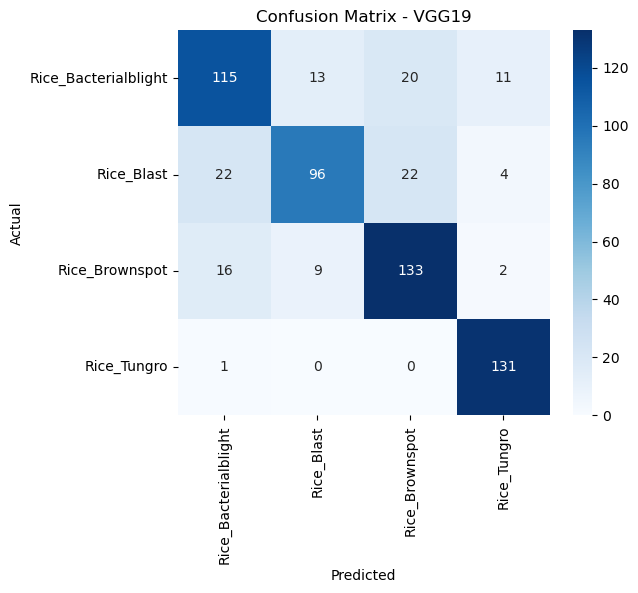

In [14]:
mob_acc, mob_report, y_true, y_pred = evaluate_model(model_vgg)

print("MobileNetV2 Accuracy:", mob_acc)
print(mob_report)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=test_generator.class_indices.keys(),
    yticklabels=test_generator.class_indices.keys()
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - VGG19")

plt.show()

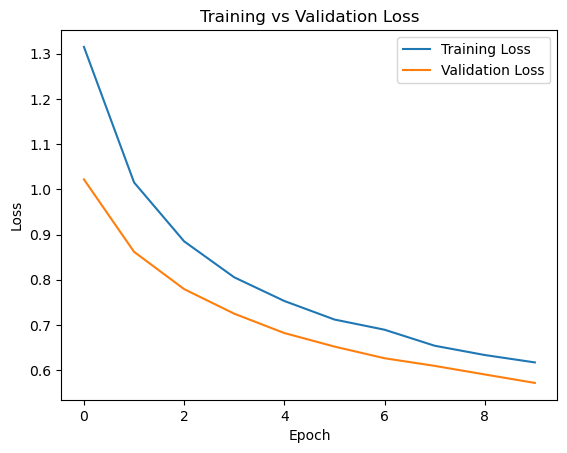

In [15]:
plt.plot(history_vgg.history['loss'], label='Training Loss')
plt.plot(history_vgg.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [18]:
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, accuracy_score
import numpy as np
path = "F:/Office/Project2026/PlantDiseaseTransformer/"
vgg = load_model(path+"model/VGG19_rice_disease.h5")
mobilenet = load_model(path+"model/MobileNetV2_rice_disease.h5")
xception = load_model(path+"model/Xception_rice_disease.h5")

In [20]:
def evaluate_model(model):

    predictions = model.predict(test_generator)

    y_pred = np.argmax(predictions, axis=1)
    y_true = test_generator.classes

    acc = accuracy_score(y_true, y_pred)

    report = classification_report(y_true, y_pred)

    return acc, report

In [21]:
vgg_acc, vgg_report = evaluate_model(vgg)
mob_acc, mob_report = evaluate_model(mobilenet)
xcep_acc, xcep_report = evaluate_model(xception)

print("VGG19 Accuracy:", vgg_acc)
print(vgg_report)

print("MobileNetV2 Accuracy:", mob_acc)
print(mob_report)

print("Xception Accuracy:", xcep_acc)
print(xcep_report)

19/19 [==============================] - 40s 2s/step
VGG19 Accuracy: 0.7983193277310925
              precision    recall  f1-score   support

           0       0.75      0.72      0.73       159
           1       0.81      0.67      0.73       144
           2       0.76      0.83      0.79       160
           3       0.89      0.99      0.94       132

    accuracy                           0.80       595
   macro avg       0.80      0.80      0.80       595
weighted avg       0.80      0.80      0.79       595

MobileNetV2 Accuracy: 0.9831932773109243
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       159
           1       0.96      0.97      0.97       144
           2       0.98      0.97      0.98       160
           3       1.00      1.00      1.00       132

    accuracy                           0.98       595
   macro avg       0.98      0.98      0.98       595
weighted avg       0.98      0.98      0.98       595

X

In [22]:
results = {
    "VGG19": vgg_acc,
    "MobileNetV2": mob_acc,
    "Xception": xcep_acc
}

best_model = max(results, key=results.get)

print("Best Model:", best_model)
print("Best Accuracy:", results[best_model])

Best Model: MobileNetV2
Best Accuracy: 0.9831932773109243


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
def plot_confusion_matrix(model, model_name):

    predictions = model.predict(test_generator)

    y_pred = np.argmax(predictions, axis=1)
    y_true = test_generator.classes

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=test_generator.class_indices.keys(),
        yticklabels=test_generator.class_indices.keys()
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix - " + model_name)

    plt.show()

19/19 [==============================] - 128s 7s/step


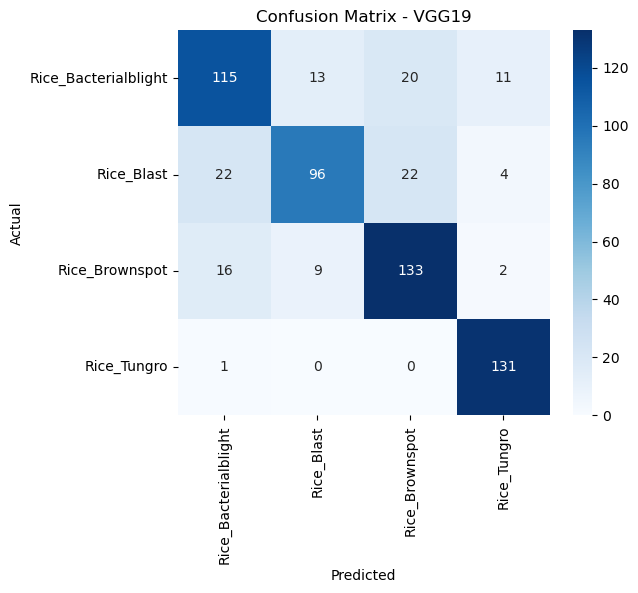

In [24]:
plot_confusion_matrix(model_vgg, "VGG19")

19/19 [==============================] - 7s 350ms/step


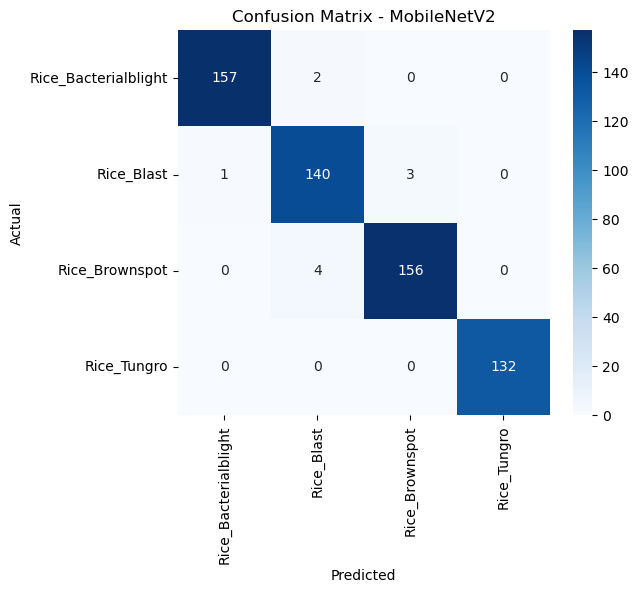

In [26]:
plot_confusion_matrix(mobilenet, "MobileNetV2")

19/19 [==============================] - 39s 2s/step


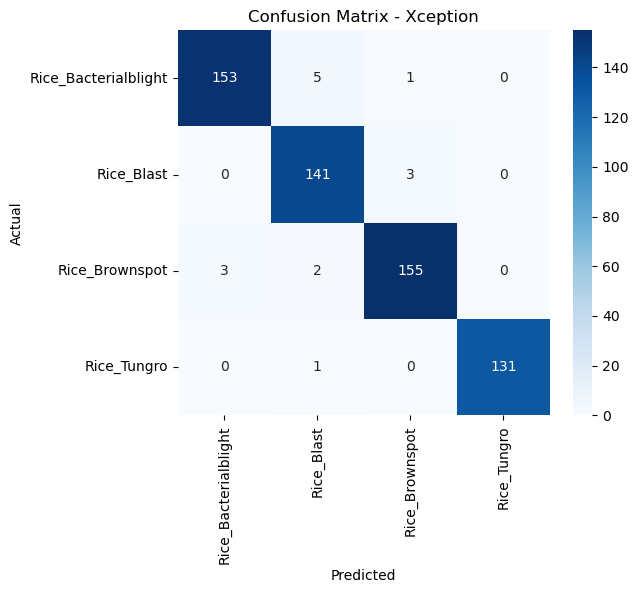

In [27]:
plot_confusion_matrix(xception, "Xception")

In [29]:
if best_model == "VGG19":
    final_model = model_vgg
elif best_model == "MobileNetV2":
    final_model = mobilenet
else:
    final_model = xception

In [30]:
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_disease(img_path):

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)

    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = final_model.predict(img_array)

    class_index = np.argmax(prediction)

    classes = list(train_generator.class_indices.keys())

    disease = classes[class_index]

    confidence = round(100 * np.max(prediction),2)

    print("Predicted Disease:", disease)
    print("Confidence:", confidence,"%")

In [31]:
predict_disease(path+"Dataset/train/Rice_Bacterialblight/BACTERAILBLIGHT3_002.jpg")

1/1 [==============================] - 1s 824ms/step
Predicted Disease: Rice_Bacterialblight
Confidence: 92.81 %


In [32]:
predict_disease(path+"Dataset/train/Rice_Tungro/TUNGRO1_013.jpg")

1/1 [==============================] - 0s 50ms/step
Predicted Disease: Rice_Tungro
Confidence: 99.97 %
